# Clasificacion de Residuos - Modelo Simple

**Proyecto:** Clasificacion Automatica de Residuos mediante Deep Learning  
**Asignatura:** Aprendizaje Profundo  
**Entrega 2:** Modelos Baseline Lineal 

---

## Objetivos del Notebook

Este notebook implementa un pipeline baseline para clasificacion de residuos usando caracteristicas HOG y un modelo lineal multinomial. Los objetivos son:

1. **Cargar** el dataset preprocesado y verificar su consistencia.
2. **Dividir** el conjunto en train/validacion/test de forma estratificada.
3. **Extraer** caracteristicas HOG para representar las imagenes.
4. **Entrenar** un modelo de regresion logistica multinomial.
5. **Evaluar** el rendimiento con metricas estandar.
6. **Reportar** resultados y parametros del modelo.

In [ ]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import numpy as np
from pathlib import Path
import sys
import warnings

# Visualizacion
import matplotlib.pyplot as plt

# Skimage
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage import exposure

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
 )

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

## 2. Carga de datos y configuración

Se carga automáticamente el dataset desde el archivo .npz y se realiza la división estratificada.

In [3]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


## 3. Extracción de características HOG

Los descriptores HOG se calculan dentro del pipeline durante el GridSearch. Los parámetros HOG (especialmente `pixels_per_cell`) se optimizan para balancear capacidad de representación y generalización.

In [4]:
# ========================================
# 3. EXTRACCION DE CARACTERISTICAS HOG
# ========================================

from sklearn.base import BaseEstimator, TransformerMixin

class HOGTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    ):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.block_norm = block_norm

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for img in X:
            gray = rgb2gray(img)
            feat = hog(
                gray,
                orientations=self.orientations,
                pixels_per_cell=self.pixels_per_cell,
                cells_per_block=self.cells_per_block,
                block_norm=self.block_norm,
                feature_vector=True,
            )
            features.append(feat)
        return np.array(features)

## 4. GridSearch y entrenamiento del modelo

Se entrena el modelo mediante un GridSearch **simplificado** para rapidez:
- **Regularización** (C): dos valores [0.1, 0.5] 
- **Resolución HOG** (pixels_per_cell): celdas grandes [(24,24), (32,32)] para reducir features
- **Solver**: lbfgs (más rápido que saga)
- **Paralelización**: usa todos los cores disponibles

Solo **12 fits** en total (4 combinaciones × 3-fold CV).

In [9]:
# ========================================
# 4. GRIDSEARCH Y ENTRENAMIENTO DEL MODELO
# ========================================
warnings.filterwarnings("ignore", category=UserWarning, module="skimage")

pipeline = Pipeline(
    steps=[
        ("hog", HOGTransformer()),
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                multi_class="multinomial",
                solver="lbfgs", 
                max_iter=2000,
                class_weight="balanced",
                n_jobs=-1, 
                random_state=44,
            ),
        ),
    ]
)

# Grid simplificado para rapidez: 4 combinaciones × 3-fold = 12 fits
param_grid = {
    # Valores de regularización
    "clf__C": [0.1, 0.5], 
    # Celdas grandes para reducir features
    "hog__pixels_per_cell": [(24, 24), (32, 32)], # determina el tamaño de las celdas para HOG
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=44)
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,  # paraleliza los folds
    verbose=0,
)

print("Iniciando GridSearch:")
print(f"Total de combinaciones: {len(param_grid['clf__C']) * len(param_grid['hog__pixels_per_cell'])} × 3-fold CV = 12 fits")
grid.fit(X_train, y_train)

print("\nMejores hiperparámetros:")
print(grid.best_params_)
print(f"Mejor F1 macro (CV): {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Iniciando GridSearch:
Total de combinaciones: 4 × 3-fold CV = 12 fits


/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/sklearn/linear_mo


Mejores hiperparámetros:
{'clf__C': 0.1, 'hog__pixels_per_cell': (32, 32)}
Mejor F1 macro (CV): 0.5104


## 5. Función de evaluación

Se define una función unificada para calcular métricas clave y generar el reporte de clasificación por clase.

In [10]:
def evaluate_model(model, X, y, split_name):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y, y_pred,
        average='macro',
        zero_division=0
    )

    print(f"\nResultados en {split_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    return acc, prec, rec, f1

## 6. Evaluación en particiones

Se evalúa el mejor modelo del GridSearch en train, validación y test para verificar generalización. Se presentan:
- **Métricas detalladas**: Accuracy, Precision, Recall, F1-Score para cada partición
- **Matrices de confusión**: Para visualizar patrones de error
- **Comparación visual**: Gráficos de barras de las métricas

In [11]:
results_train = evaluate_model(best_model, X_train, y_train, "TRAIN")
results_val   = evaluate_model(best_model, X_val,   y_val,   "VALIDACION")
results_test  = evaluate_model(best_model, X_test,  y_test,  "TEST")

# Resumen comparativo
print("\nResumen comparativo de métricas:")
print(f"{'Partición':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"{'-'*12} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"{'Train':<12} {results_train[0]:>10.4f} {results_train[1]:>10.4f} {results_train[2]:>10.4f} {results_train[3]:>10.4f}")
print(f"{'Validación':<12} {results_val[0]:>10.4f} {results_val[1]:>10.4f} {results_val[2]:>10.4f} {results_val[3]:>10.4f}")
print(f"{'Test':<12} {results_test[0]:>10.4f} {results_test[1]:>10.4f} {results_test[2]:>10.4f} {results_test[3]:>10.4f}")


Resultados en TRAIN:
  Accuracy:  0.9955
  Precision: 0.9946
  Recall:    0.9965
  F1-score:  0.9955

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.99      1.00      1.00       282
       glass       1.00      0.99      1.00       350
       metal       1.00      1.00      1.00       287
       paper       1.00      0.99      0.99       416
     plastic       0.99      1.00      1.00       337
       trash       0.99      1.00      0.99        96

    accuracy                           1.00      1768
   macro avg       0.99      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768


Resultados en VALIDACION:
  Accuracy:  0.5013
  Precision: 0.5000
  Recall:    0.5065
  F1-score:  0.5023

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.70      0.64      0.67        61
       glass       0.49      0.47      0.48        75
       metal       0.34      0.34    

### 6.1. Matrices de confusión

Visualización de las matrices de confusión para cada partición (train, validación y test) para identificar patrones de error.

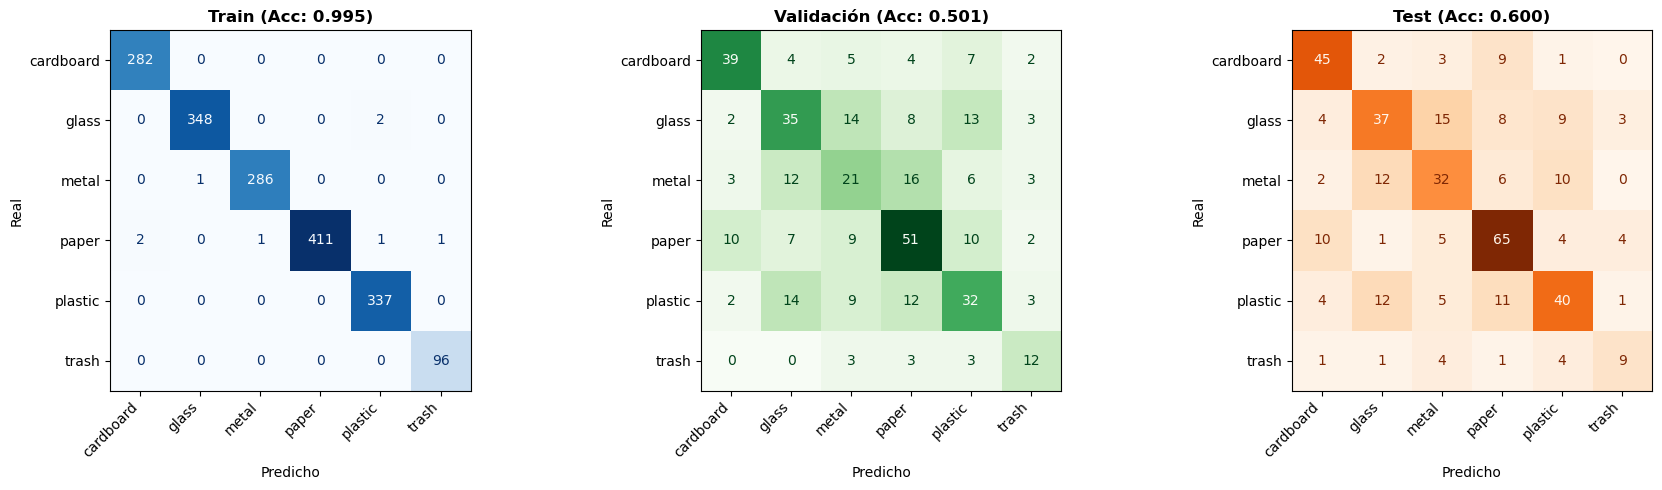

In [12]:
# Matrices de confusión para Train, Val y Test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicciones
y_pred_train = best_model.predict(X_train)
y_pred_val = best_model.predict(X_val)
y_pred_test = best_model.predict(X_test)

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Train (Acc: {results_train[0]:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicho", fontsize=10)
axes[0].set_ylabel("Real", fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validación
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Validación (Acc: {results_val[0]:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicho", fontsize=10)
axes[1].set_ylabel("Real", fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap="Oranges", colorbar=False)
axes[2].set_title(f"Test (Acc: {results_test[0]:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Predicho", fontsize=10)
axes[2].set_ylabel("Real", fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


### 6.2. Visualización de métricas

Comparación visual de las métricas entre las particiones para identificar posible overfitting o underfitting.

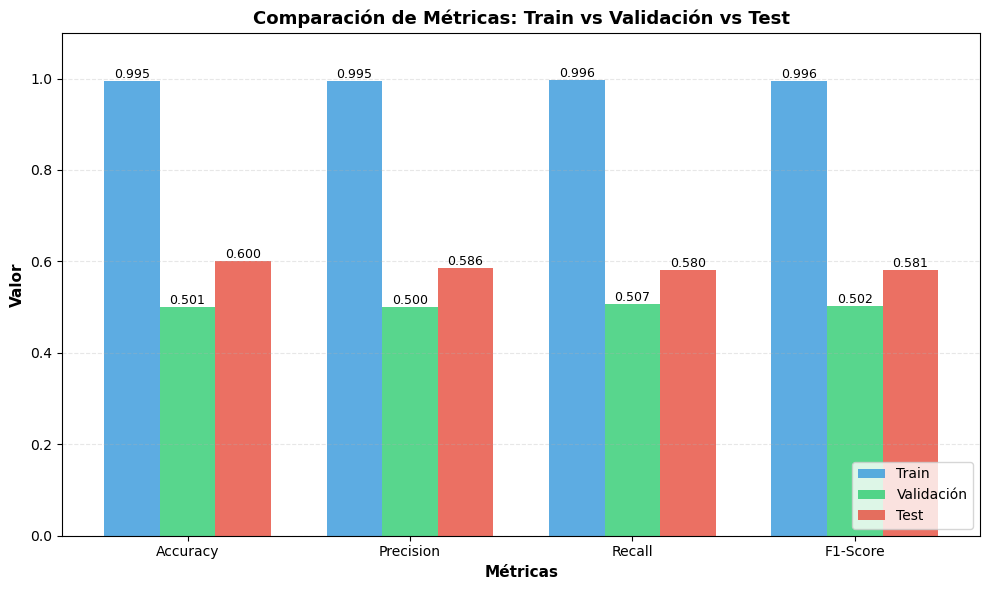

  Diferencia Accuracy (Train - Test): 0.3955

Análisis de generalización:
  Poca generalización - Overfitting severo


In [13]:
# Visualización comparativa de métricas
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_metrics = list(results_train)
val_metrics = list(results_val)
test_metrics = list(results_test)

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, train_metrics, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, val_metrics, width, label='Validación', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, test_metrics, width, label='Test', color='#e74c3c', alpha=0.8)

# Etiquetas en las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Métricas', fontweight='bold', fontsize=11)
ax.set_ylabel('Valor', fontweight='bold', fontsize=11)
ax.set_title('Comparación de Métricas: Train vs Validación vs Test', 
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Análisis de generalización
diff_train_test = results_train[0] - results_test[0]
print(f"  Diferencia Accuracy (Train - Test): {diff_train_test:.4f}")

print("\nAnálisis de generalización:")
if diff_train_test < 0.05:
    print("  Excelente generalización - No hay overfitting significativo")
elif diff_train_test < 0.10:
    print("  Buena generalización - Overfitting leve")
elif diff_train_test < 0.15:
    print("  Generalización moderada - Overfitting presente")
else:
    print("  Poca generalización - Overfitting severo")

## 7. Tamaño del modelo

En **Regresión Logística Multinomial**, cada clase tiene:
- **Coeficientes** (`coef_`): un peso por cada feature HOG
- **Intercepto** (`intercept_`): un término de sesgo

**Fórmula del número de parámetros:**
$$\text{Total} = (\text{n\_clases} \times \text{n\_features}) + \text{n\_clases}$$

Donde `n_features` depende de los parámetros HOG:
- Celdas más pequeñas → más features → más parámetros
- Celdas más grandes → menos features → menos parámetros

In [14]:
# Extraer el clasificador entrenado
clf = best_model.named_steps["clf"]

# Dimensiones de los parámetros
n_clases = len(class_names)
n_features = clf.coef_.shape[1]

# Desglose de parámetros
coef_params = clf.coef_.size  # n_clases × n_features
intercept_params = clf.intercept_.size  # n_clases

num_params = coef_params + intercept_params

print("\nAnálisis de parámetros del modelo:")
print(f"  Número de clases: {n_clases}")
print(f"  Número de features HOG: {n_features:,}")
print(f"\n  Desglose de parámetros:")
print(f"    - Coeficientes (coef_):    {n_clases} × {n_features:,} = {coef_params:,}")
print(f"    - Interceptos (intercept_): {intercept_params}")
print(f"    - TOTAL: {num_params:,}")



Análisis de parámetros del modelo:
  Número de clases: 6
  Número de features HOG: 1,296

  Desglose de parámetros:
    - Coeficientes (coef_):    6 × 1,296 = 7,776
    - Interceptos (intercept_): 6
    - TOTAL: 7,782


### 7.1. Explicación del cálculo

**¿Cómo se calculan las features HOG?**

Para una imagen de 224×224 píxeles:

1. Se divide en celdas de tamaño `pixels_per_cell`
   - Ejemplo: 24×24 → (224/24)² = 81 celdas (9×9)

2. Las celdas se agrupan en bloques de `cells_per_block` para normalización
   - Ejemplo: 2×2 celdas por bloque → 64 bloques (8×8, con solapamiento)

3. Cada bloque genera features:
   - `orientations` × `cells_per_block`²
   - Ejemplo: 9 orientaciones × 2² = 36 features por bloque

4. Total: `n_bloques × features_por_bloque` = 64 × 36 = **2,304 features**

**En el modelo lineal:**
- Cada feature HOG tiene un peso por cada clase
- Más features → más parámetros → más riesgo de overfitting
- Celdas grandes (24×24 o 32×32) reducen features pero mantienen información relevante

## 8. Resumen final

Resumen ejecutivo con todas las métricas, configuración del modelo y arquitectura para documentación y comparación con otros modelos.

In [15]:
print("\nResumen final del modelo:\n")

print("Configuración:")
print(f"  - Algoritmo: Regresión Logística Multinomial")
print(f"  - Features: HOG (Histogram of Oriented Gradients)")
print(f"  - Regularización (C): {best_model.named_steps['clf'].C}")
print(f"  - Pixels per cell: {best_model.named_steps['hog'].pixels_per_cell}")
print(f"  - Solver: {best_model.named_steps['clf'].solver}")

print("\nMétricas de rendimiento:")
print(f"  {'Partición':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Train':<12} {results_train[0]:>10.4f} {results_train[1]:>10.4f} {results_train[2]:>10.4f} {results_train[3]:>10.4f}")
print(f"  {'Validación':<12} {results_val[0]:>10.4f} {results_val[1]:>10.4f} {results_val[2]:>10.4f} {results_val[3]:>10.4f}")
print(f"  {'Test':<12} {results_test[0]:>10.4f} {results_test[1]:>10.4f} {results_test[2]:>10.4f} {results_test[3]:>10.4f}")

print("\nArquitectura:")
print(f"  - Número de parámetros: {num_params:,}")
print(f"  - Features HOG: {n_features:,}")
print(f"  - Clases: {n_clases}")


Resumen final del modelo:

Configuración:
  - Algoritmo: Regresión Logística Multinomial
  - Features: HOG (Histogram of Oriented Gradients)
  - Regularización (C): 0.1
  - Pixels per cell: (32, 32)
  - Solver: lbfgs

Métricas de rendimiento:
  Partición      Accuracy  Precision     Recall   F1-Score
  ------------ ---------- ---------- ---------- ----------
  Train            0.9955     0.9946     0.9965     0.9955
  Validación       0.5013     0.5000     0.5065     0.5023
  Test             0.6000     0.5864     0.5802     0.5815

Arquitectura:
  - Número de parámetros: 7,782
  - Features HOG: 1,296
  - Clases: 6


## 9. Interpretabilidad y diagnóstico

Se realizan análisis detallados para entender el comportamiento del modelo:

1. **Visualización HOG**: Cómo el modelo representa las imágenes mediante descriptores de gradientes
2. **Análisis de errores en Test**: Identificación de confusiones frecuentes y patrones de error para entender limitaciones del modelo

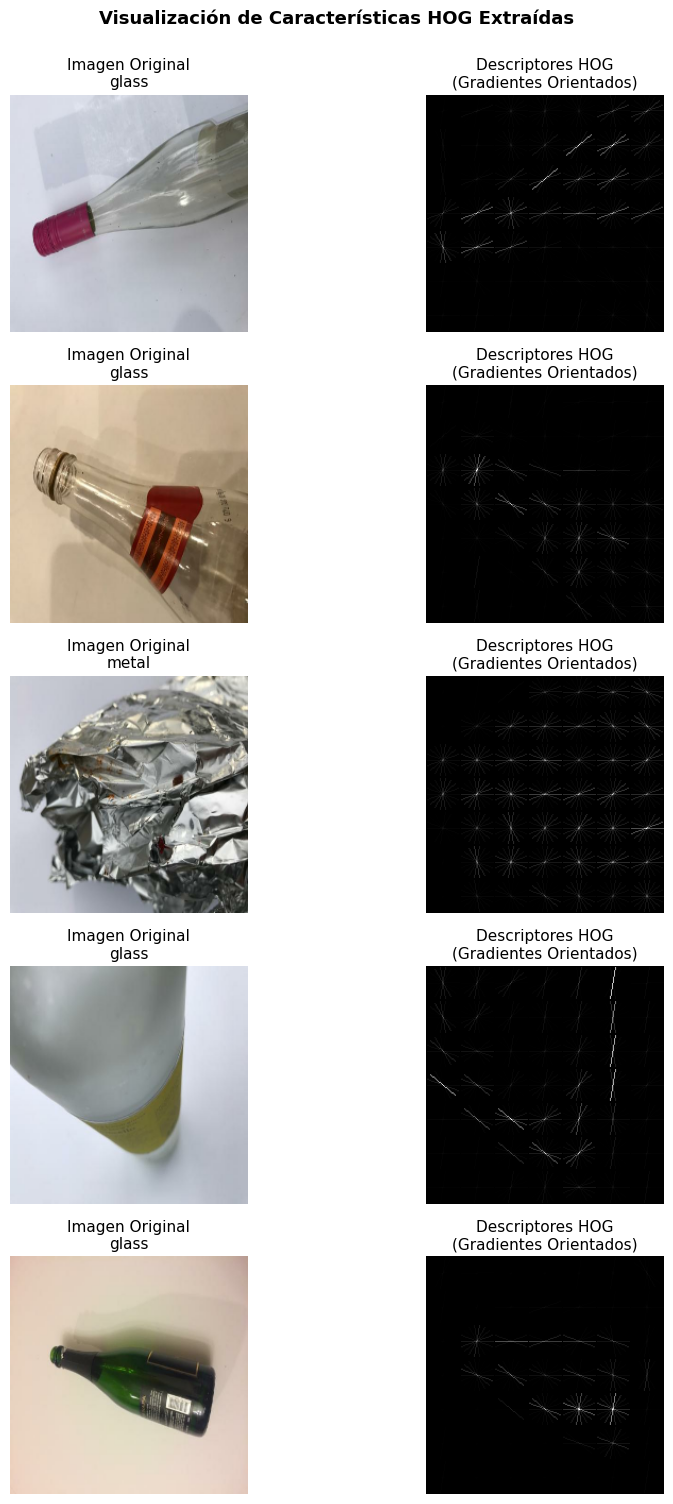

In [20]:
# ========================================
# VISUALIZACIÓN DE CARACTERÍSTICAS HOG
# ========================================

hog_step = best_model.named_steps["hog"]
orientations = hog_step.orientations
pixels_per_cell = hog_step.pixels_per_cell
cells_per_block = hog_step.cells_per_block
block_norm = hog_step.block_norm

np.random.seed(42)
sample_count = 5
sample_indices = np.random.choice(len(X_val), size=sample_count, replace=False)

fig, axes = plt.subplots(sample_count, 2, figsize=(10, 3 * sample_count))
for i, idx in enumerate(sample_indices):
    img = X_val[idx]
    gray = rgb2gray(img)
    _, hog_img = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm=block_norm,
        visualize=True,
        feature_vector=True,
    )
    hog_img = exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max()))

    axes[i, 0].imshow(img.astype(np.uint8))
    axes[i, 0].set_title(f"Imagen Original\n{class_names[y_val[idx]]}", fontsize=11)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(hog_img, cmap="gray")
    axes[i, 1].set_title("Descriptores HOG\n(Gradientes Orientados)", fontsize=11)
    axes[i, 1].axis("off")

plt.suptitle("Visualización de Características HOG Extraídas", fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



Análisis de errores de clasificación en test:
  Total de muestras en test: 380
  Predicciones correctas: 228 (60.00%)
  Predicciones incorrectas: 152 (40.00%)

  Mostrando ejemplos de errores para interpretabilidad:


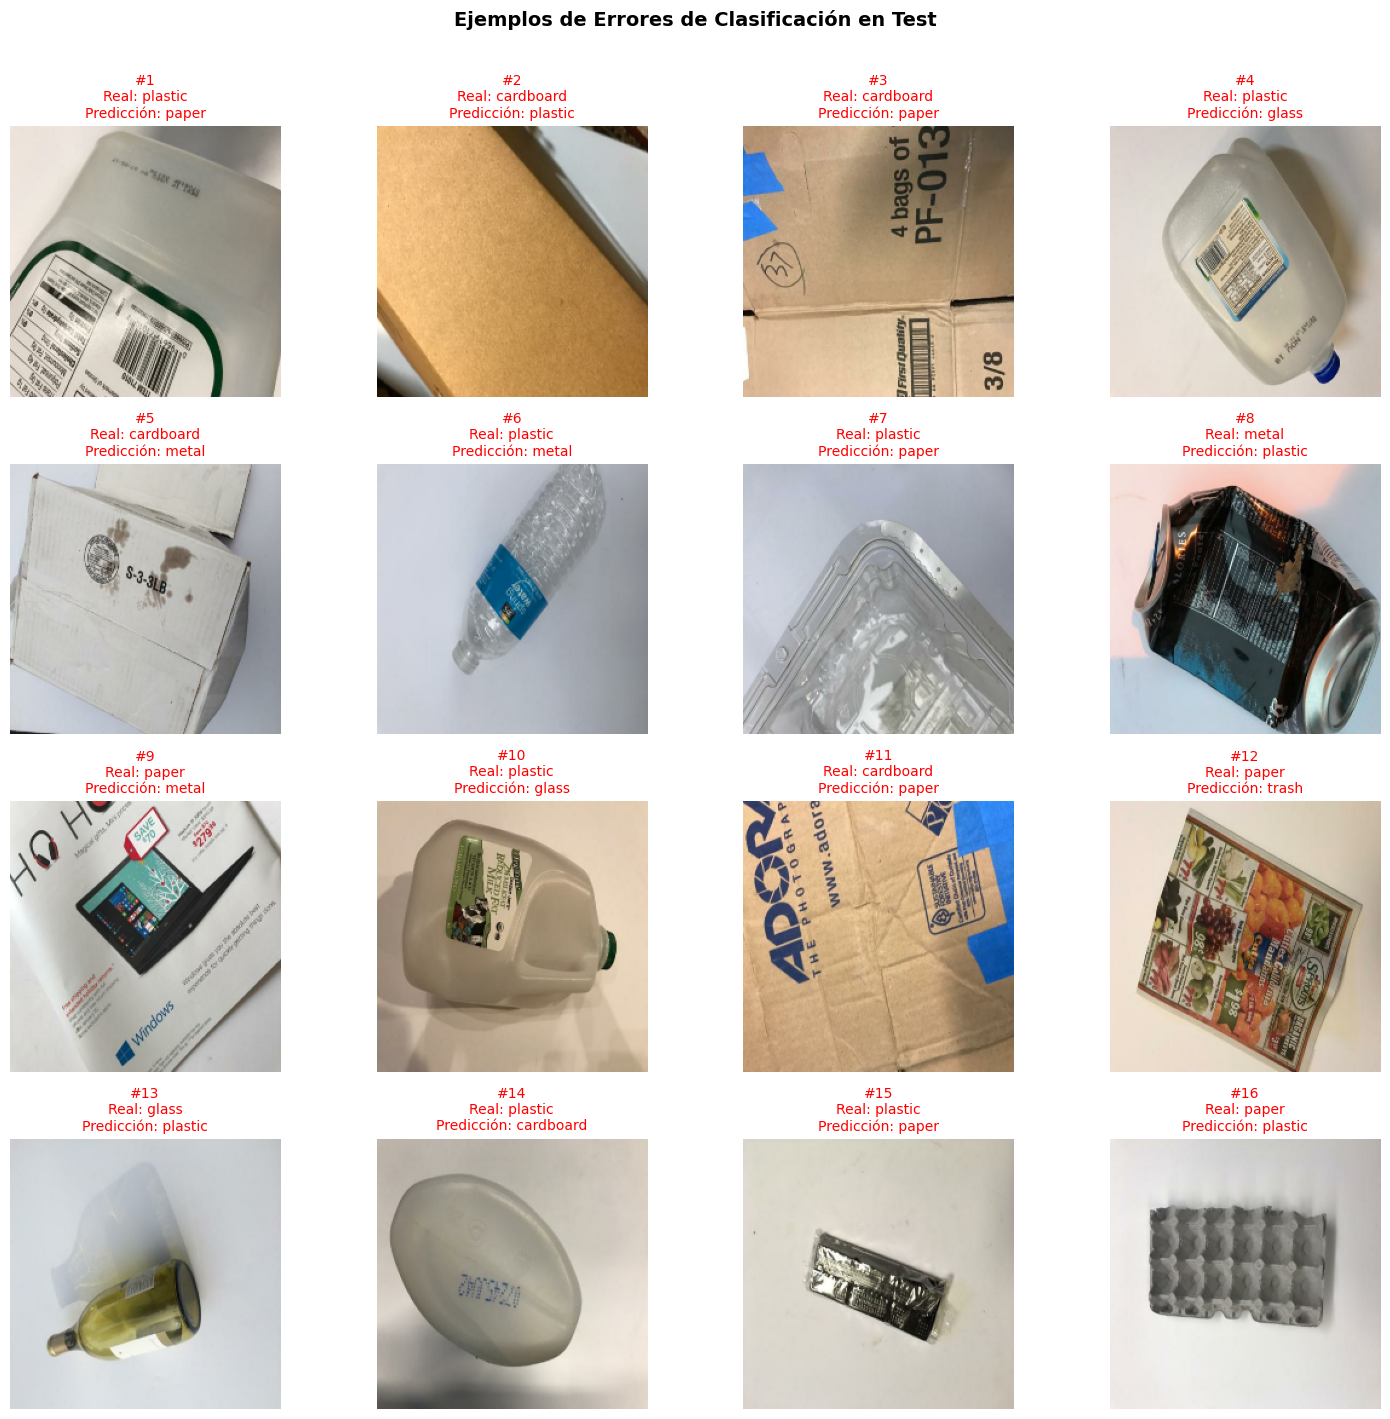


  Confusiones más frecuentes:
    glass        → metal        :  15 veces (  9.9% de los errores)
    plastic      → glass        :  12 veces (  7.9% de los errores)
    metal        → glass        :  12 veces (  7.9% de los errores)
    plastic      → paper        :  11 veces (  7.2% de los errores)
    paper        → cardboard    :  10 veces (  6.6% de los errores)


In [21]:
# Generar predicciones en test
y_pred_test_errors = best_model.predict(X_test)

# Encontrar índices de errores
mis_idx = np.where(y_pred_test_errors != y_test)[0]

print("\nAnálisis de errores de clasificación en test:")
print(f"  Total de muestras en test: {len(y_test)}")
print(f"  Predicciones correctas: {len(y_test) - len(mis_idx)} ({(len(y_test)-len(mis_idx))/len(y_test)*100:.2f}%)")
print(f"  Predicciones incorrectas: {len(mis_idx)} ({len(mis_idx)/len(y_test)*100:.2f}%)")

if len(mis_idx) == 0:
    print("\n  Clasificación perfecta en test.")
else:
    # Mostrar ejemplos visuales de errores
    print(f"\n  Mostrando ejemplos de errores para interpretabilidad:")
    
    show_n = min(16, len(mis_idx))
    np.random.seed(42)
    chosen = np.random.choice(mis_idx, size=show_n, replace=False)
    
    cols = 4
    rows = int(np.ceil(show_n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, idx) in enumerate(zip(axes, chosen)):
        img = X_test[idx].astype(np.uint8)
        true_lbl = class_names[y_test[idx]]
        pred_lbl = class_names[y_pred_test_errors[idx]]
        
        ax.imshow(img)
        ax.set_title(f"#{i+1}\nReal: {true_lbl}\nPredicción: {pred_lbl}", 
                     fontsize=10, color='red')
        ax.axis("off")
    
    # Ocultar ejes vacíos
    for ax in axes[show_n:]:
        ax.axis("off")
    
    plt.suptitle("Ejemplos de Errores de Clasificación en Test", 
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    
    # Análisis de confusiones más comunes
    print("\n  Confusiones más frecuentes:")
    error_pairs = []
    for idx in mis_idx:
        true_class = class_names[y_test[idx]]
        pred_class = class_names[y_pred_test_errors[idx]]
        error_pairs.append((true_class, pred_class))
    
    from collections import Counter
    most_common = Counter(error_pairs).most_common(5)
    
    for (true_cls, pred_cls), count in most_common:
        print(f"    {true_cls:12} → {pred_cls:12} : {count:3} veces ({count/len(mis_idx)*100:5.1f}% de los errores)")
    